# CN 1 : Test of Data Class

In [1]:
# import useful libraries
import numpy as np
import matplotlib.pyplot as plt

import os
import sys

# add parent directory to sys.path to import STL package modules
PARENT_DIR = os.path.dirname(os.path.abspath(os.getcwd() + "../../../"))
sys.path.append(PARENT_DIR)
print("Parent directory added to sys.path:", ".../" + PARENT_DIR.split("/")[-1])

# test data directory
DATA_TEST_PATH = PARENT_DIR + "/data" + "/test"
print("Dataset dirctory used:", ".../" + PARENT_DIR.split("/")[-1] + DATA_TEST_PATH.split(PARENT_DIR.split("/")[-1])[-1])


from STL_main.STL_2D_FFT_Torch import STL_2D_FFT_Torch, WavelateOperator2D_FFT_torch
DataClass = STL_2D_FFT_Torch
WaveletOperatorClass = WavelateOperator2D_FFT_torch
from STL_main.torch_backend import _DEFAULT_DEVICE

print("Working on device:", _DEFAULT_DEVICE)

Parent directory added to sys.path: .../c:\Users\Danie\Bureau\STL-Dev
Dataset dirctory used: .../c:\Users\Danie\Bureau\STL-Dev/data/test
Working on device: cpu


In [2]:
# command to auto-reload modules when they are edited (easier for testing and debugging)
%load_ext autoreload
%autoreload 2

shape data = (256, 256)
shape data_full = (20, 256, 256)


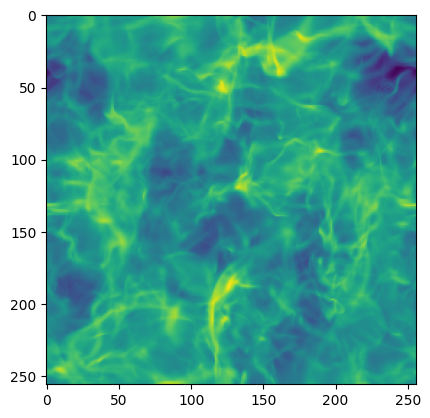

In [3]:
# Load some data and visualize it 
data_full = np.load(str(DATA_TEST_PATH) + "/" + "Turb_6.npy")
data = data_full[0] 

print("shape data = " + str(data.shape)) # (height, width)
print("shape data_full = " + str(data_full.shape)) # (N_images, height, width)

plt.imshow(data)

#### Data Class instance and parameters

In [4]:
# test initilization of STL_2D_FFT_Torch class
stl_data_type_full = DataClass(array=data_full)
stl_data_type = DataClass(array=data)

In [5]:
print("Attributes of stl_data_type_full:\n")
for attr, value in stl_data_type_full.__dict__.items():
    print(attr, "=", value)
    print()

Attributes of stl_data_type_full:

DT = Planar2D_FFT_torch

dg = 0

N0 = (256, 256)

array = tensor([[[20.1753, 20.1603, 20.1411,  ..., 20.1628, 20.1684, 20.1840],
         [20.1410, 20.1371, 20.1369,  ..., 20.1435, 20.1255, 20.1532],
         [20.1368, 20.1340, 20.1359,  ..., 20.1287, 20.1163, 20.1409],
         ...,
         [20.2385, 20.1890, 20.1470,  ..., 20.3206, 20.3140, 20.2882],
         [20.2286, 20.1976, 20.1556,  ..., 20.2404, 20.2510, 20.2498],
         [20.2046, 20.1793, 20.1461,  ..., 20.1950, 20.2152, 20.2231]],

        [[20.2139, 20.2218, 20.2298,  ..., 20.1676, 20.1856, 20.2012],
         [20.2164, 20.2211, 20.2248,  ..., 20.1771, 20.1929, 20.2067],
         [20.2289, 20.2256, 20.2285,  ..., 20.2074, 20.2212, 20.2288],
         ...,
         [20.2976, 20.3174, 20.3337,  ..., 20.2624, 20.2667, 20.2801],
         [20.2602, 20.2743, 20.2731,  ..., 20.2105, 20.2226, 20.2407],
         [20.2283, 20.2384, 20.2428,  ..., 20.1792, 20.1948, 20.2114]],

        [[20.5281, 20.4

In [6]:
print("Attributes of stl_data_type:\n")
for attr, value in stl_data_type.__dict__.items():
    print(attr, "=", value)
    print()

Attributes of stl_data_type:

DT = Planar2D_FFT_torch

dg = 0

N0 = (256, 256)

array = tensor([[20.1753, 20.1603, 20.1411,  ..., 20.1628, 20.1684, 20.1840],
        [20.1410, 20.1371, 20.1369,  ..., 20.1435, 20.1255, 20.1532],
        [20.1368, 20.1340, 20.1359,  ..., 20.1287, 20.1163, 20.1409],
        ...,
        [20.2385, 20.1890, 20.1470,  ..., 20.3206, 20.3140, 20.2882],
        [20.2286, 20.1976, 20.1556,  ..., 20.2404, 20.2510, 20.2498],
        [20.2046, 20.1793, 20.1461,  ..., 20.1950, 20.2152, 20.2231]],
       dtype=torch.float64)

fourier_status = False

device = cpu

dtype = torch.float64

pbc = None

conv_history = []



## Standard Data 

#### Downsampling

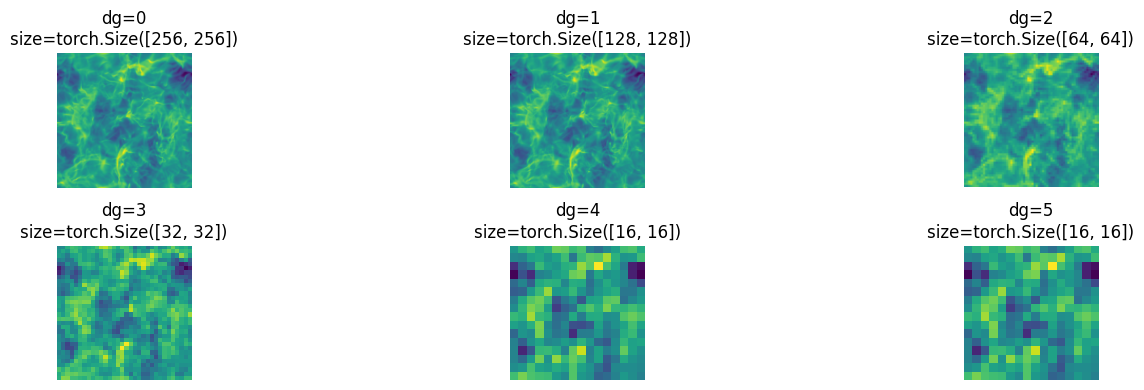

In [7]:
# Let's downsample some data and see if it works
# downsampling method is attached to the Wavelet Operator instances


fig, axes = plt.subplots(2, 3, figsize=(16, 4))
axes = axes.flatten()


for dg, ax in enumerate(axes):

    # Subsample data
    stl_data_dg = WaveletOperatorClass.downsample(data=stl_data_type, 
                                                  dg_out=dg, 
                                                  inplace=False,
                                                  target_fourier_status=False)

    ax.imshow(stl_data_dg.array.cpu().numpy().real)
    
    ax.set_title(f"dg={dg}\nsize={stl_data_dg.array.shape}")  
    ax.axis('off')

plt.tight_layout()
plt.show()


#### Mean

In [8]:
wavelet_op = stl_data_type.get_wavelet_op()

mean = wavelet_op.mean(data=stl_data_type.set_fourier_status(target_fourier_status=True, inplace=False), wavelet_convolved=False)
print("Mean of stl_data_type:", mean)

mean_full = wavelet_op.mean(data=stl_data_type_full, wavelet_convolved=False)
print("Mean of stl_data_type_full:", mean_full)

Mean of stl_data_type: tensor(20.3195+0.j, dtype=torch.complex128)
Mean of stl_data_type_full: tensor([20.3195, 20.3212, 20.3036, 20.2935, 20.3115, 20.2913, 20.2600, 20.2831,
        20.3128, 20.3132, 20.3141, 20.3182, 20.3239, 20.3129, 20.3045, 20.2958,
        20.2791, 20.2668, 20.2587, 20.2797], dtype=torch.float64)


#### Covariance

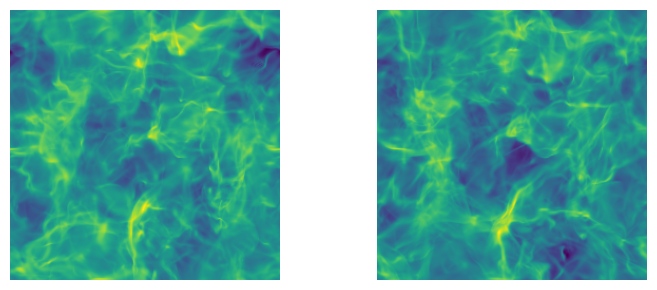

Data0 Fourier status is : False
Data1 Fourier status is : False
Covariance in real space = tensor(0.0247, dtype=torch.float64)

Data0 Fourier status is : True
Data1 Fourier status is : True
Covariance in Fourier space = tensor(0.0247-4.3368e-19j, dtype=torch.complex128)


In [9]:
# Prepare centralized data for covariance tests
data0 = data_full[0]
data1 = data_full[1]
data0 = data0 - mean_full[0].item()
data1 = data1 - mean_full[1].item()
stl_data0 = DataClass(data0)
stl_data1 = DataClass(data1)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes = axes.ravel()
axes[0].imshow(stl_data0.array.cpu().numpy())
axes[0].axis('off')
axes[1].imshow(stl_data1.array.cpu().numpy())
axes[1].axis('off')
plt.tight_layout()
plt.show()

# Test of Cov in real space (by default fourier_status=False)
print("Data0 Fourier status is : " + str(stl_data0.fourier_status))
print("Data1 Fourier status is : " + str(stl_data1.fourier_status))
cov = wavelet_op.cov(stl_data0, stl_data1, wavelet_convolved=False)
print("Covariance in real space = " + str(cov))
print()

# Test of Cov in real space
stl_data1.set_fourier_status(target_fourier_status=True, inplace=True)
stl_data0.set_fourier_status(target_fourier_status=True, inplace=True)
print("Data0 Fourier status is : " + str(stl_data0.fourier_status))
print("Data1 Fourier status is : " + str(stl_data1.fourier_status))
cov = wavelet_op.cov(stl_data0, stl_data1, wavelet_convolved=False)
print("Covariance in Fourier space = " + str(cov))


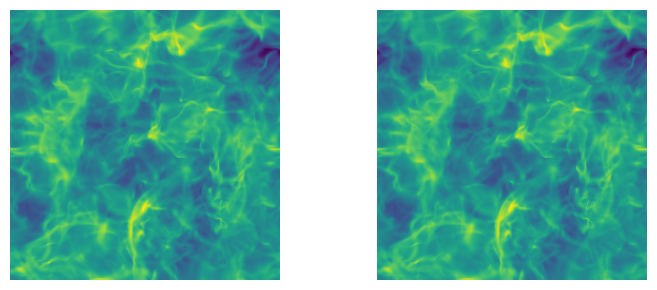

Data0 Fourier status is : False
Data1 Fourier status is : False
Covariance in real space = tensor(0.0641, dtype=torch.float64)

Data0 Fourier status is : True
Data1 Fourier status is : True
Covariance in Fourier space = tensor(0.0641+7.0595e-21j, dtype=torch.complex128)


In [12]:
# Auto-covariance test
data0 = data_full[0]
data1 = data_full[0]
data0 = data0 - mean_full[0].item()
data1 = data1 - mean_full[1].item()
stl_data0 = DataClass(data0)
stl_data1 = DataClass(data1)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes = axes.ravel()
axes[0].imshow(stl_data0.array.cpu().numpy())
axes[0].axis('off')
axes[1].imshow(stl_data1.array.cpu().numpy())
axes[1].axis('off')
plt.tight_layout()
plt.show()

# Test of Cov in real space (by default fourier_status=False)
print("Data0 Fourier status is : " + str(stl_data0.fourier_status))
print("Data1 Fourier status is : " + str(stl_data1.fourier_status))
cov = wavelet_op.cov(stl_data0, stl_data1, wavelet_convolved=False)
print("Covariance in real space = " + str(cov))
print()


# Test of Cov in real space
stl_data1.set_fourier_status(target_fourier_status=True, inplace=True)
stl_data0.set_fourier_status(target_fourier_status=True, inplace=True)
print("Data0 Fourier status is : " + str(stl_data0.fourier_status))
print("Data1 Fourier status is : " + str(stl_data1.fourier_status))
cov = wavelet_op.cov(stl_data0, stl_data1, wavelet_convolved=False)
print("Covariance in Fourier space = " + str(cov))


## Non-Standard Data

#### Downsampling

shape cropped data = torch.Size([115, 235])


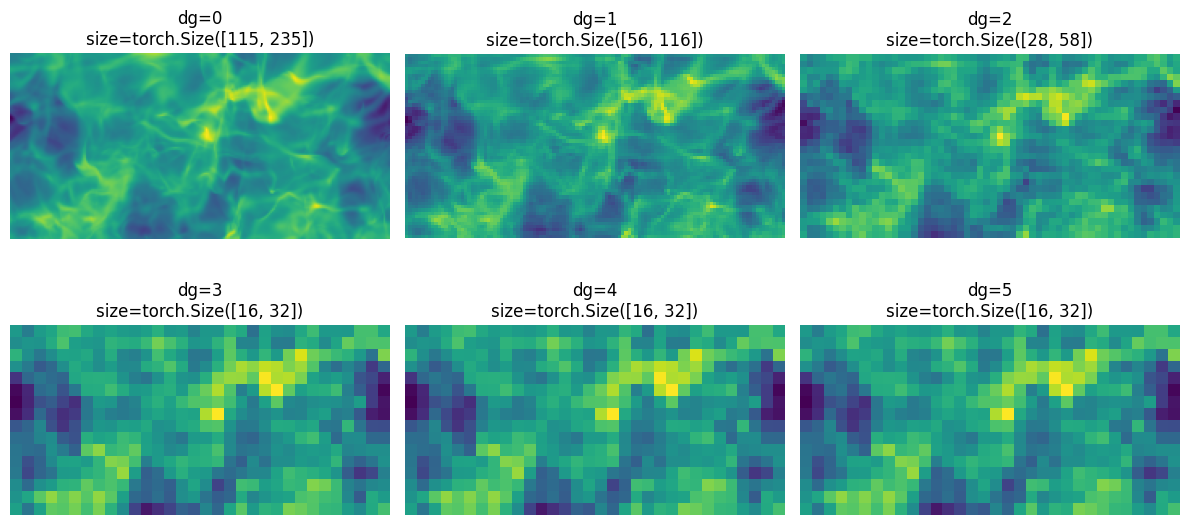

In [13]:
# Let's test the same downsampling method with non regular sizes

stl_data_type_no_standard = DataClass(array=data[:115, :235])
print("shape cropped data = " + str(stl_data_type_no_standard.array.shape))

# Prepare plot
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.ravel()

# perform 8 downgrading and plot
for dg, ax in enumerate(axes):

    # Subsample data
    stl_data_crop_dg = WaveletOperatorClass.downsample(data=stl_data_type_no_standard, 
                                                       dg_out=dg, 
                                                       inplace=False,
                                                       target_fourier_status=False)
    
    
    ax.imshow(stl_data_crop_dg.array.cpu().numpy().real)
    ax.set_title(f"dg={dg}\nsize={stl_data_crop_dg.array.shape}")  
    ax.axis('off')

plt.tight_layout()
plt.show()

# Same issue here as before.

#### Mean

In [15]:
wavelet_op_no_standard = stl_data_type_no_standard.get_wavelet_op()

mean_no_standard = wavelet_op_no_standard.mean(data=stl_data_type_no_standard, wavelet_convolved=False)
print("Mean of stl_data_type_no_standard:", mean_no_standard)

Mean of stl_data_type_no_standard: tensor(20.3317, dtype=torch.float64)


#### Covariance

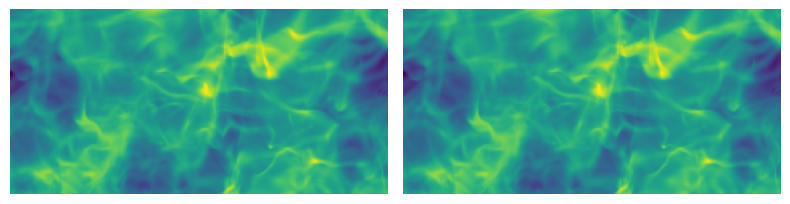

Data0 Fourier status is : False
Data1 Fourier status is : False
Covariance in real space = tensor(0.0682, dtype=torch.float64)

Data0 Fourier status is : True
Data1 Fourier status is : True
Covariance in Fourier space = tensor(0.0682+0.j, dtype=torch.complex128)


In [16]:
# Auto-covariance test for non standard size data
stl_data0 = DataClass(array=stl_data_type_no_standard.array -  mean_full[0].item())
stl_data1 = DataClass(array=stl_data_type_no_standard.array - mean_full[0].item())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes = axes.ravel()
axes[0].imshow(stl_data0.array.cpu().numpy())
axes[0].axis('off')
axes[1].imshow(stl_data1.array.cpu().numpy())
axes[1].axis('off')
plt.tight_layout()
plt.show()

# Test of Cov in real space (by default fourier_status=False)
print("Data0 Fourier status is : " + str(stl_data0.fourier_status))
print("Data1 Fourier status is : " + str(stl_data1.fourier_status))
cov = wavelet_op.cov(stl_data0, stl_data1, wavelet_convolved=False)
print("Covariance in real space = " + str(cov))
print()

# Test of Cov in real space
stl_data1.set_fourier_status(target_fourier_status=True, inplace=True)
stl_data0.set_fourier_status(target_fourier_status=True, inplace=True)
print("Data0 Fourier status is : " + str(stl_data0.fourier_status))
print("Data1 Fourier status is : " + str(stl_data1.fourier_status))
cov = wavelet_op.cov(stl_data0, stl_data1, wavelet_convolved=False)
print("Covariance in Fourier space = " + str(cov))
